In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SemanticSegDataset(Dataset):
    def __init__(self, rgb_dir, mask_dir, rgb_transform=None, mask_transform=None):
        self.rgb_dir = rgb_dir
        self.mask_dir = mask_dir
        self.rgb_transform = rgb_transform
        self.mask_transform = mask_transform
        self.filenames = sorted(os.listdir(rgb_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        rgb_name = self.filenames[idx]
        rgb_path = os.path.join(self.rgb_dir, rgb_name)
        mask_name = rgb_name.replace("rgb", "semantic")
        mask_path = os.path.join(self.mask_dir, mask_name)

        rgb = Image.open(rgb_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.rgb_transform:
            rgb = self.rgb_transform(rgb)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return rgb, mask

In [3]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

rgb_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

mask_transform = T.Compose([
    T.Resize((256, 256), interpolation=Image.NEAREST),
    T.PILToTensor(),  # Keeps integer labels
])

train_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/Semantic", rgb_transform, mask_transform)
val_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/Semantic", rgb_transform, mask_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# Data Analysis

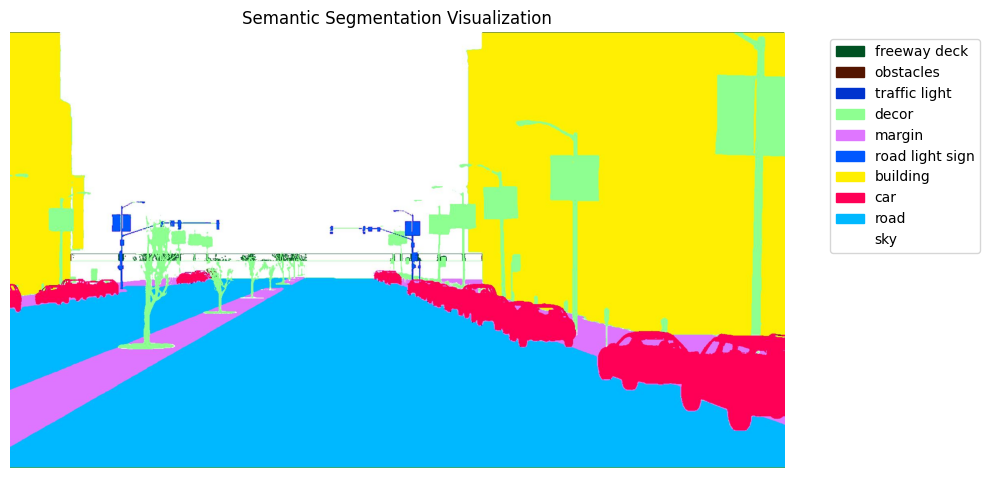

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

# === Your class color mapping ===
class_colors = {
    "freeway deck": [0, 81, 34],
    "obstacles": [84, 21, 0],
    "traffic light": [0, 51, 206],
    "decor": [142, 255, 145],
    "margin": [223, 118, 255],
    "road light sign": [0, 88, 255],
    "building": [255, 239, 0],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

# === Convert class_colors to RGB tuple format ===
color_to_label = {tuple(v): k for k, v in class_colors.items()}

# === Load the semantic segmentation image ===
semantic_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg"  # Replace with your path
semantic_image = Image.open(semantic_path).convert("RGB")
semantic_np = np.array(semantic_image)

# === Plot the image ===
plt.figure(figsize=(10, 10))
plt.imshow(semantic_np)
plt.axis("off")
plt.title("Semantic Segmentation Visualization")

# === Create legend patches ===
patches = [
    mpatches.Patch(color=np.array(rgb) / 255.0, label=label)
    for rgb, label in color_to_label.items()
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [5]:
from tqdm import tqdm 

Processing images: 100%|██████████| 1720/1720 [19:49<00:00,  1.45it/s]


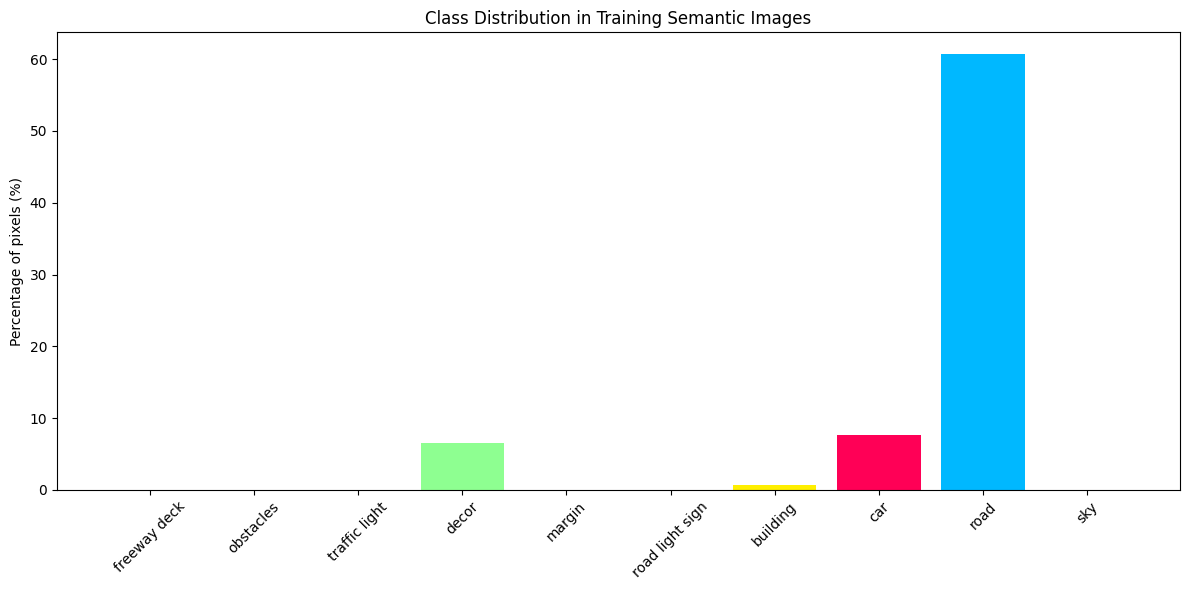

In [7]:
color_to_class = {tuple(v): k for k, v in class_colors.items()}
semantic_folder = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/Semantic"

# Init pixel counter
class_pixel_counts = {cls: 0 for cls in class_colors}

# Get all image filenames
image_filenames = [f for f in os.listdir(semantic_folder) if f.endswith((".png", ".jpg"))]

# Loop with progress bar
for filename in tqdm(image_filenames, desc="Processing images"):
    image_path = os.path.join(semantic_folder, filename)
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    for color, class_name in color_to_class.items():
        mask = np.all(image_np == color, axis=-1)
        class_pixel_counts[class_name] += np.sum(mask)

# Normalize to percentage
total_pixels = sum(class_pixel_counts.values())
class_percentages = {
    cls: (count / total_pixels) * 100 for cls, count in class_pixel_counts.items()
}

# === Plot ===
plt.figure(figsize=(12, 6))
plt.bar(class_percentages.keys(), class_percentages.values(), color=[np.array(class_colors[c])/255 for c in class_colors])
plt.xticks(rotation=45)
plt.ylabel("Percentage of pixels (%)")
plt.title("Class Distribution in Training Semantic Images")
plt.tight_layout()
plt.show()

# Train

In [8]:
import torchvision.models.segmentation as models
import torch.nn as nn
import torch

NUM_CLASSES = 10  # Change to your actual number of classes

model = models.deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:00<00:00, 197MB/s]  


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [14]:
class_colors = {
    "freeway deck": [0, 81, 34],
    "obstacles": [84, 21, 0],
    "traffic light": [0, 51, 206],
    "decor": [142, 255, 145],
    "margin": [223, 118, 255],
    "road light sign": [0, 88, 255],
    "building": [255, 239, 0],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

# Convert to color_to_class with integer indices
color_to_class = {tuple(rgb): idx for idx, (class_name, rgb) in enumerate(class_colors.items())}

# Define rgb_to_class_indices (as above)
def rgb_to_class_indices(batch_rgb_masks, color_to_class):
    batch_class_masks = []
    for rgb_mask in batch_rgb_masks:
        rgb_mask = rgb_mask.transpose(1, 2, 0)  # (C, H, W) to (H, W, C)
        class_mask = np.zeros(rgb_mask.shape[:2], dtype=np.int64)
        for color, class_idx in color_to_class.items():
            mask = np.all(rgb_mask == np.array(color), axis=-1)
            class_mask[mask] = class_idx
        batch_class_masks.append(torch.tensor(class_mask, dtype=torch.long))
    return torch.stack(batch_class_masks)

# Initialize criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Ensure model is on the correct device

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, rgb_masks in train_loader:
        images = images.to(device)
        
        # Convert the RGB masks in the batch to class indices
        masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class)
        masks = masks.to(device)  # Move the masks to the same device as the model

        outputs = model(images)['out']
        
        # Compute loss
        loss = criterion(outputs, masks)

        # Backpropagate and update the weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")

Epoch 1/10, Loss: 231.9260
Epoch 2/10, Loss: 83.9644
Epoch 3/10, Loss: 66.0012
Epoch 4/10, Loss: 58.3588
Epoch 5/10, Loss: 54.0624
Epoch 6/10, Loss: 49.8494
Epoch 7/10, Loss: 47.3542
Epoch 8/10, Loss: 60.4479
Epoch 9/10, Loss: 49.0163
Epoch 10/10, Loss: 44.2809


In [16]:
# Save model weights
torch.save(model.state_dict(), "segmentation_model.pth")

In [18]:
class_colors = {
    "freeway deck": [0, 81, 34],
    "obstacles": [84, 21, 0],
    "traffic light": [0, 51, 206],
    "decor": [142, 255, 145],
    "margin": [223, 118, 255],
    "road light sign": [0, 88, 255],
    "building": [255, 239, 0],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

# Convert to color_to_class with integer indices
color_to_class = {tuple(rgb): idx for idx, (class_name, rgb) in enumerate(class_colors.items())}

# Function to convert RGB masks to class indices
def rgb_to_class_indices(batch_rgb_masks, color_to_class):
    batch_class_masks = []
    for rgb_mask in batch_rgb_masks:
        rgb_mask = rgb_mask.transpose(1, 2, 0)  # (C, H, W) to (H, W, C)
        class_mask = np.zeros(rgb_mask.shape[:2], dtype=np.int64)
        for color, class_idx in color_to_class.items():
            mask = np.all(rgb_mask == np.array(color), axis=-1)
            class_mask[mask] = class_idx
        batch_class_masks.append(torch.tensor(class_mask, dtype=torch.long))
    return torch.stack(batch_class_masks)

# Initialize criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # Ensure model is on the correct device

# Lists to store metrics
epoch_losses = []
epoch_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    total_correct = 0
    total_pixels = 0
    
    # Progress bar for batches
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch")
    
    for images, rgb_masks in progress_bar:
        images = images.to(device)
        
        # Convert the RGB masks in the batch to class indices
        masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)['out']
        
        # Compute loss
        loss = criterion(outputs, masks)
        total_loss += loss.item()

        # Compute accuracy
        preds = torch.argmax(outputs, dim=1)  # Get predicted class indices
        correct = (preds == masks).sum().item()
        total_correct += correct
        total_pixels += masks.numel()

        # Backpropagate and update the weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update progress bar with current loss
        progress_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})

    # Calculate average loss and accuracy for the epoch
    avg_loss = total_loss / len(train_loader)
    accuracy = total_correct / total_pixels * 100  # Convert to percentage
    
    epoch_losses.append(avg_loss)
    epoch_accuracies.append(accuracy)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Optional: Print or save final metrics
print("\nTraining Summary:")
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}: Loss = {epoch_losses[epoch]:.4f}, Accuracy = {epoch_accuracies[epoch]:.2f}%")

Epoch 1/10: 100%|██████████| 430/430 [03:28<00:00,  2.07batch/s, Batch Loss=0.0737]


Epoch 1/10, Loss: 0.1038, Accuracy: 95.92%


Epoch 2/10: 100%|██████████| 430/430 [03:24<00:00,  2.10batch/s, Batch Loss=0.1226]


Epoch 2/10, Loss: 0.0994, Accuracy: 96.07%


Epoch 3/10: 100%|██████████| 430/430 [03:27<00:00,  2.08batch/s, Batch Loss=0.1139]


...

Epoch 8/10, Loss: 0.0842, Accuracy: 96.58%


Epoch 9/10: 100%|██████████| 430/430 [03:24<00:00,  2.10batch/s, Batch Loss=0.1172]


Epoch 9/10, Loss: 0.0838, Accuracy: 96.59%


Epoch 10/10: 100%|██████████| 430/430 [03:24<00:00,  2.10batch/s, Batch Loss=0.0565]

Epoch 10/10, Loss: 0.0826, Accuracy: 96.64%

Training Summary:
Epoch 1: Loss = 0.1038, Accuracy = 95.92%
Epoch 2: Loss = 0.0994, Accuracy = 96.07%
Epoch 3: Loss = 0.0965, Accuracy = 96.15%
Epoch 4: Loss = 0.0914, Accuracy = 96.33%
Epoch 5: Loss = 0.0908, Accuracy = 96.34%
Epoch 6: Loss = 0.0896, Accuracy = 96.39%
Epoch 7: Loss = 0.0874, Accuracy = 96.46%
Epoch 8: Loss = 0.0842, Accuracy = 96.58%
Epoch 9: Loss = 0.0838, Accuracy = 96.59%
Epoch 10: Loss = 0.0826, Accuracy = 96.64%


# Test model

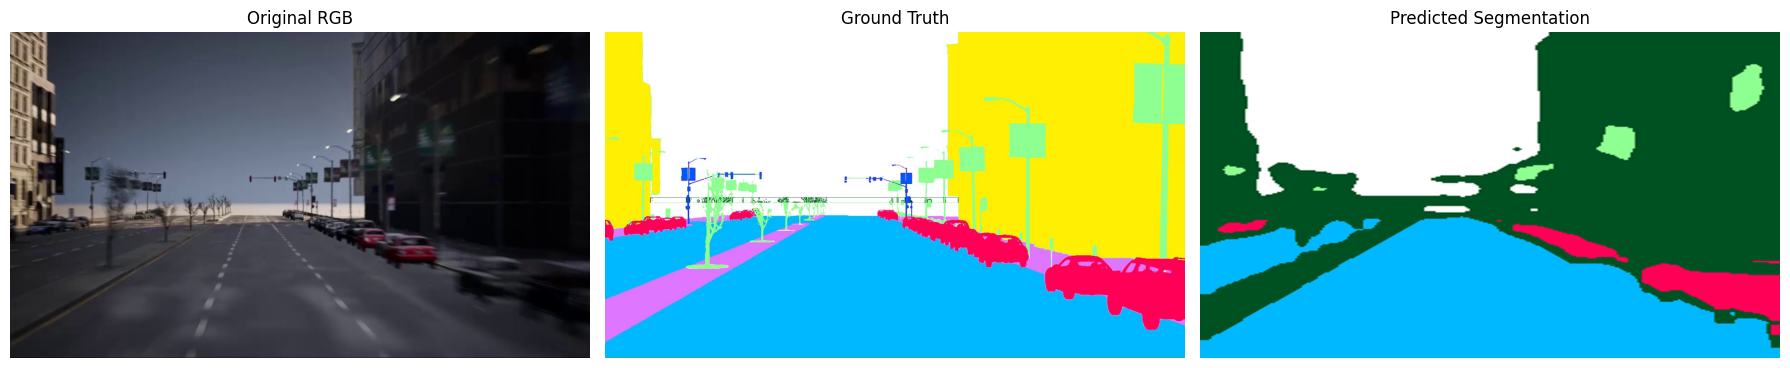

In [36]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

model.eval()

rgb_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/RGB/rgb_frame_1000.jpg"               # ← Update
gt_mask_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg" # ← Update

# Load RGB and GT mask
image = Image.open(rgb_path).convert("RGB")
gt_mask = Image.open(gt_mask_path).convert("RGB")
original_size = image.size

# Transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Process input image
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
model.eval()
with torch.no_grad():
    output = model(input_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# Decode prediction
def decode_segmentation(mask, class_colors):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, (class_name, color) in enumerate(class_colors.items()):
        color_mask[mask == idx] = color
    return color_mask

pred_color = decode_segmentation(pred, class_colors)
pred_image_resized = Image.fromarray(pred_color).resize(original_size)

# Plot
plt.figure(figsize=(18, 6))

# Original RGB
plt.subplot(1, 3, 1)
plt.title("Original RGB")
plt.imshow(image)
plt.axis("off")

# Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(gt_mask)
plt.axis("off")

# Predicted Segmentation
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation")
plt.imshow(pred_image_resized)
plt.axis("off")

plt.tight_layout()
plt.show()

### Sky Misclassification:
Ground Truth: The sky (white, [255, 255, 255], class index 9) is correctly labeled across the top portion of the image.
Predicted: The sky is partially misclassified as another class (e.g., green [142, 255, 145], which corresponds to "decor", class index 3). This suggests the model struggles to distinguish the sky from other classes with similar features.
### Road Misclassification:
Ground Truth: The road (cyan, [0, 184, 255], class index 8) is consistently labeled across the street.
Predicted: Some road areas are misclassified as purple ([223, 118, 255], "margin", class index 4) or other colors, indicating confusion between road and adjacent classes like margins or obstacles.
### Cars and Small Objects:
Ground Truth: Cars (red, [255, 0, 86], class index 7) are accurately segmented in small regions.
Predicted: Some cars are missing or misclassified, possibly due to their small size or similarity to other classes (e.g., "obstacles" or "building").
### General Observation:
The model captures the overall structure (e.g., road and sky boundaries) but struggles with fine details and class boundaries, leading to noisy predictions.